In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import compute_AR_from_Q, day_plot


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'

dataset = nc.Dataset(fname)

lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))

def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2

dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])

x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [17]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_eddies_processed.pkl')
df_eddies


,Day,Eddy,Cyc,lon,lat,ic,jc,xc,yc,w,...,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname
0,1462,1,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000011,...,0.918433,-0.656814,1.558529,118.032741,47.992205,1.969122,74.597458,107,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
1,1463,1,CE,160.820027,-29.753172,257,272,905.254559,1345.866439,-0.000018,...,1.537559,-0.243165,0.688838,108.004573,52.019741,1.602291,68.599374,107,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
2,1464,1,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000011,...,1.237644,-0.119636,0.819551,141.148836,74.035424,1.269457,78.300764,107,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
3,1465,1,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000016,...,1.404286,-0.325607,0.787603,111.650721,56.591801,1.544380,69.625773,107,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
4,1466,1,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000014,...,1.181141,-0.435550,1.007249,115.925719,57.471319,1.538338,72.613632,107,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106155,10646,2826,CE,153.757172,-37.513498,182,61,518.287017,300.848692,-0.000026,...,1.036141,-0.109348,0.988587,91.984251,31.359836,1.138712,46.900904,28,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
106156,10647,2826,CE,153.687115,-37.523299,181,60,512.684226,297.695084,-0.000027,...,1.031585,0.002212,0.969387,78.707595,25.393893,1.031663,44.896186,28,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
106157,10648,2826,CE,153.699708,-37.537452,181,60,514.199660,296.590511,-0.000026,...,1.010390,0.013422,0.989895,61.298208,19.369553,1.017029,38.796956,28,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
106158,10649,2826,CE,153.682657,-37.451789,180,62,510.019363,305.068558,-0.000025,...,1.126718,-0.048147,0.889591,64.546558,19.604126,1.136121,40.028670,28,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...


In [3]:
df_doppio = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_DOPPIO_SEACOFS_26yr.pkl')
df_doppio['w'] *= 1e-3; df_doppio['Omega0'] *= 1e-3; df_doppio['Omega'] *= 1e-3; #df_doppio['psi0'] *= 1e9
df_doppio


,Day,fnumber,nxc,nyc,nCyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R
0,1462,1461,830.0,1515.0,AE,829.879126,1515.297884,0.000016,"[[0.7054724746035225, -0.17299518294950286], [...",0.000007,0.000008,96.456316,-38.462785,63.384028
1,1462,1461,358.0,1408.0,AE,357.902634,1407.794571,0.000032,"[[1.2525415454561337, -0.37318304544145586], [...",0.000015,0.000014,78.042405,-41.260426,50.068171
2,1462,1461,928.0,1356.0,CE,928.181752,1356.070550,-0.000011,"[[0.9184334895938384, -0.6568144522261018], [-...",-0.000004,-0.000007,118.032741,47.992205,74.597458
3,1462,1461,506.0,1354.0,CE,505.750855,1353.499933,-0.000032,"[[1.0915204469734063, -0.17483272531676586], [...",-0.000016,-0.000013,106.666574,75.106895,69.457705
4,1462,1461,754.0,1285.0,AE,753.849693,1284.689807,0.000022,"[[1.300245004042572, -0.37537759847059776], [-...",0.000010,0.000008,103.327517,-44.066805,65.961546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416246,10650,10641,349.0,158.0,AE,348.663439,158.138527,0.000033,"[[1.3863808771116255, 0.04649055064735413], [0...",0.000016,0.000012,110.552001,-72.997132,43.099927
416247,10650,10641,973.0,126.0,CE,978.294053,127.970950,-0.000004,"[[0.6233322936879349, -0.5502050858849237], [-...",-0.000001,-0.000002,75.127332,4.241051,34.482872
416248,10650,10641,805.0,95.0,AE,804.765913,95.382012,0.000011,"[[1.2619918374118362, 0.3980497594289241], [0....",0.000005,0.000006,60.426625,-10.779905,45.893895
416249,10650,10641,157.0,34.0,CE,157.210669,33.449590,-0.000007,"[[0.9874338034387458, 0.628992620695803], [0.6...",-0.000003,-0.000004,141.142981,36.082072,34.764443


In [4]:
df_doppio['err'] = np.hypot(
    df_doppio['xc'].values - df_doppio['nxc'].values,
    df_doppio['yc'].values - df_doppio['nyc'].values
)
df_doppio['AR'] = compute_AR_from_Q(np.stack(df_doppio['Q'].values))


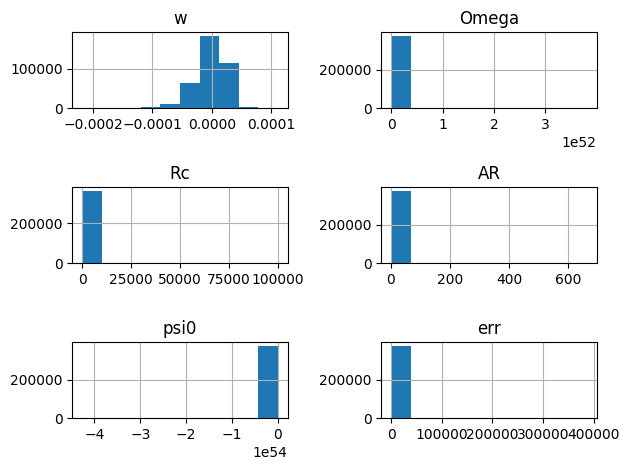

In [5]:
df_doppio.hist(['w', 'Omega', 'Rc', 'AR', 'psi0', 'err'])
plt.tight_layout()


In [8]:
df_doppio['Cyc'] = np.where(df_doppio.w >0, 'AE', 'CE')


In [11]:
df_doppio['Eddy'] = df_doppio.groupby('Day').cumcount()


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


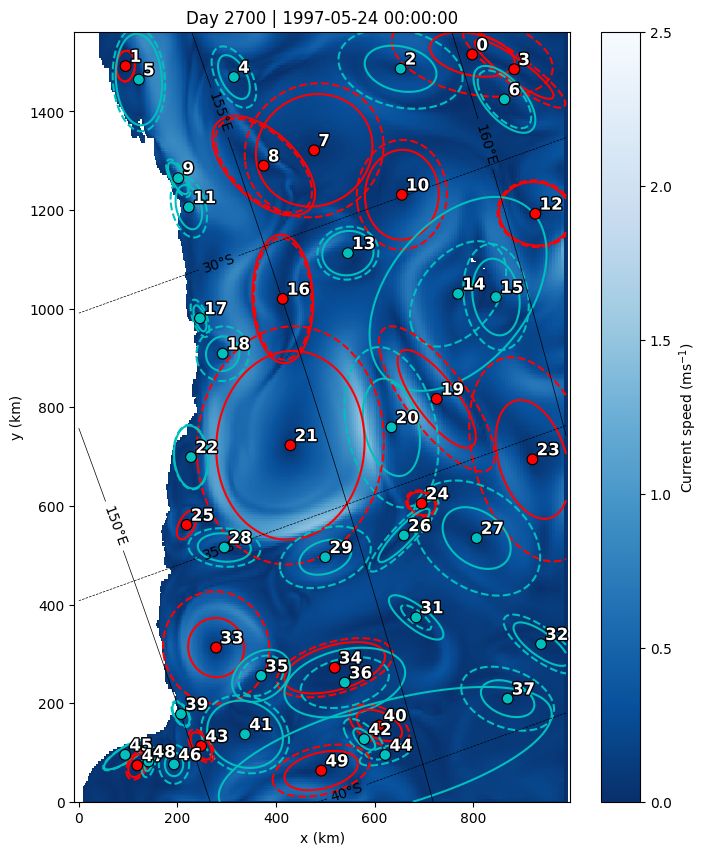

In [15]:
day_plot(2700, df_doppio, out_core_flag=True)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


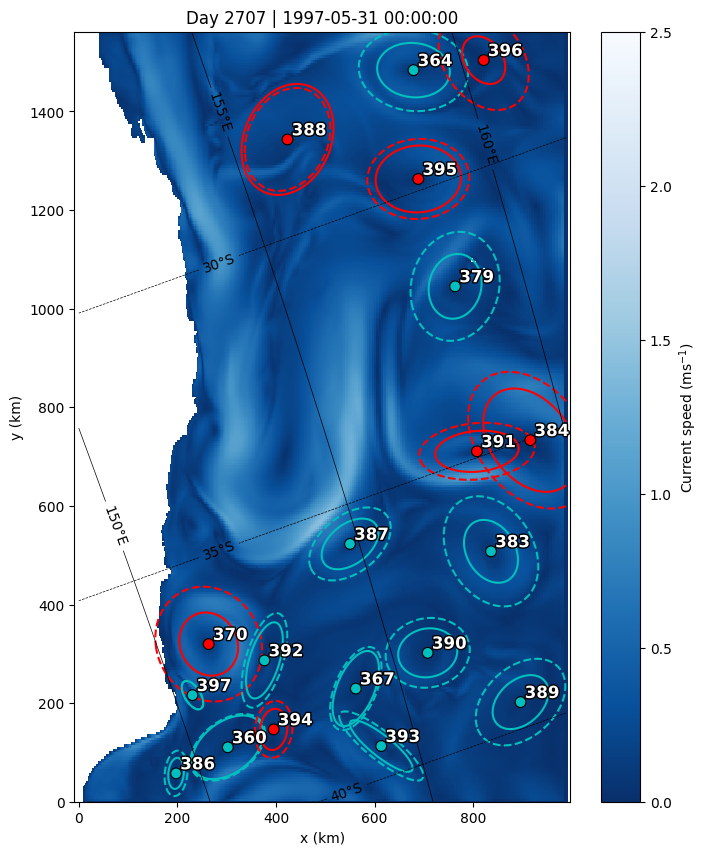

In [16]:
day_plot(2707, df_eddies, out_core_flag=True)
